### Task 1: Exploratory Data Analysis (EDA)

1.	Load the dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
df=pd.read_csv('Pharma_Industry.csv')

In [4]:
df.shape

(500, 6)

In [5]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [6]:
#  check duplicated values
df.duplicated().sum()

np.int64(0)

In [7]:
# check missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

<Axes: >

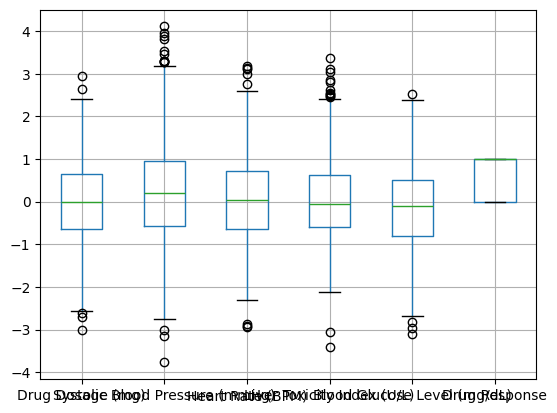

In [8]:
# outliers detection
df.boxplot()

In [9]:
#  outliers capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+ 1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

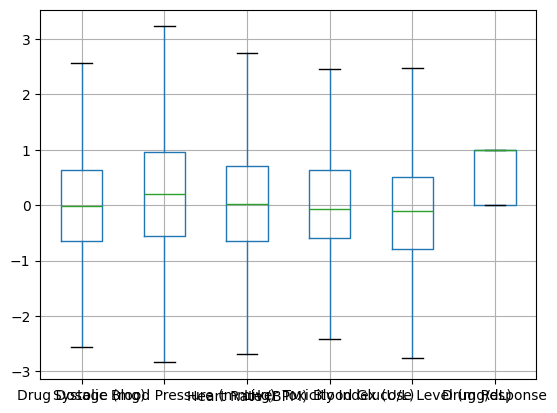

In [10]:
df.boxplot()
plt.show()

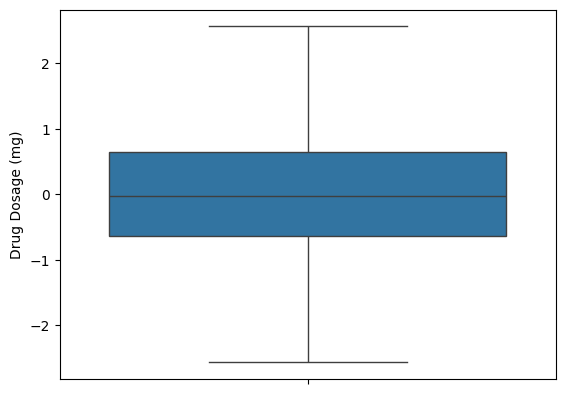

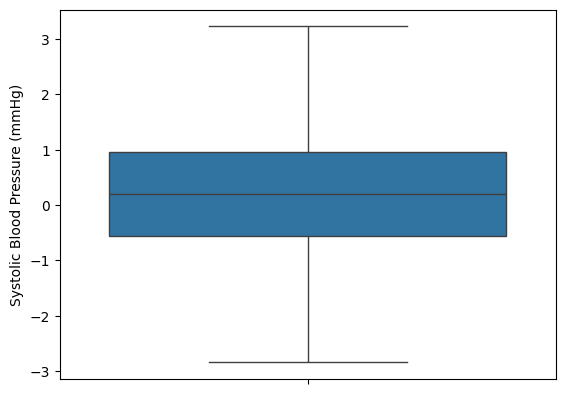

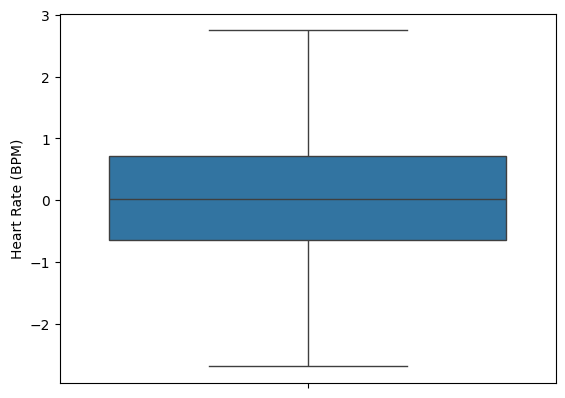

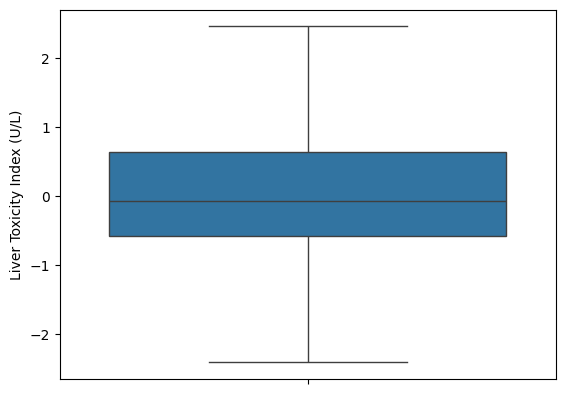

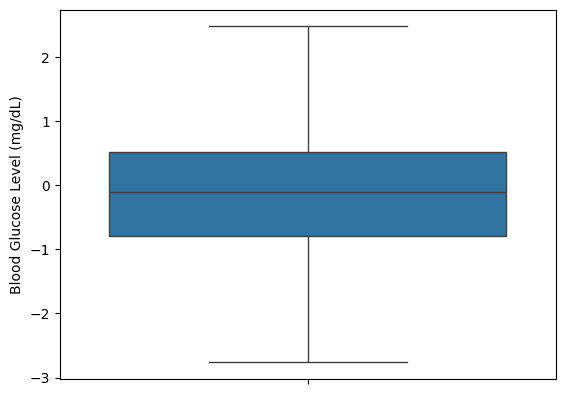

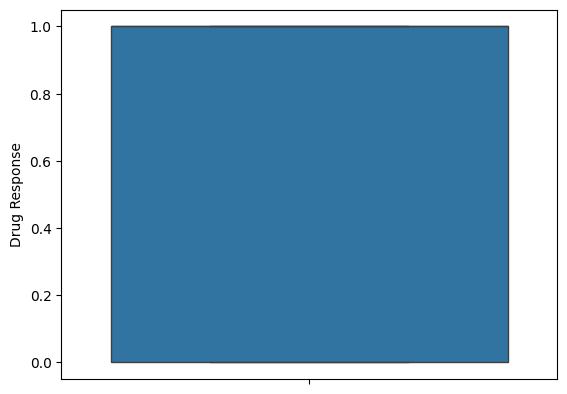

In [11]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [12]:
## selection of features
features= df.drop(columns=['Drug Response'])
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


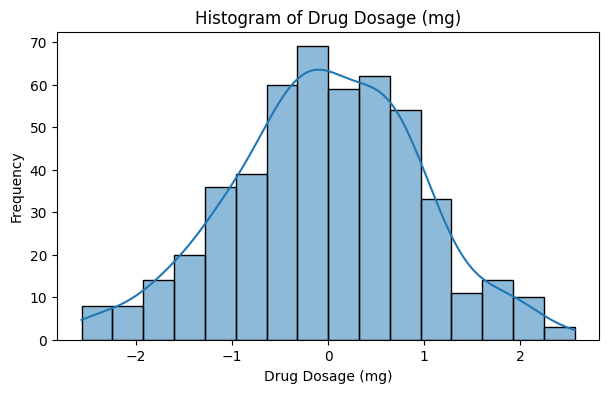

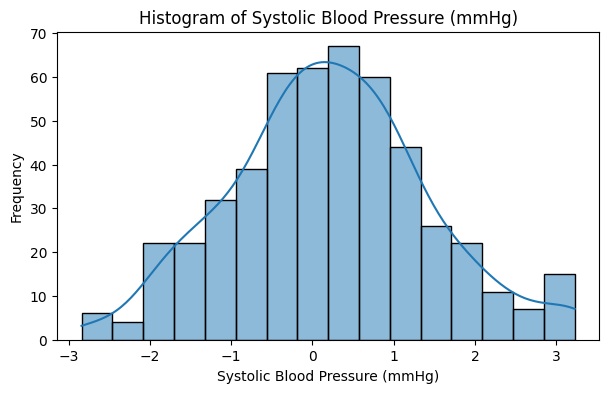

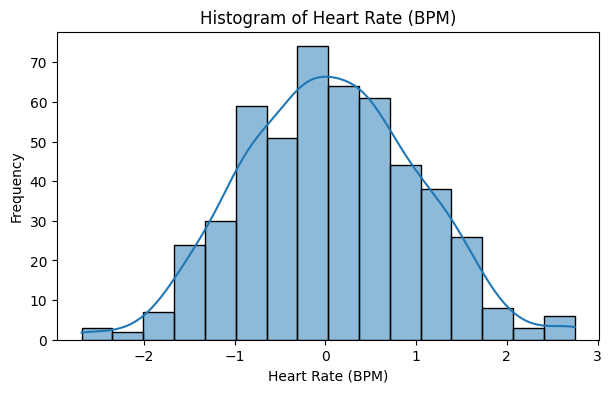

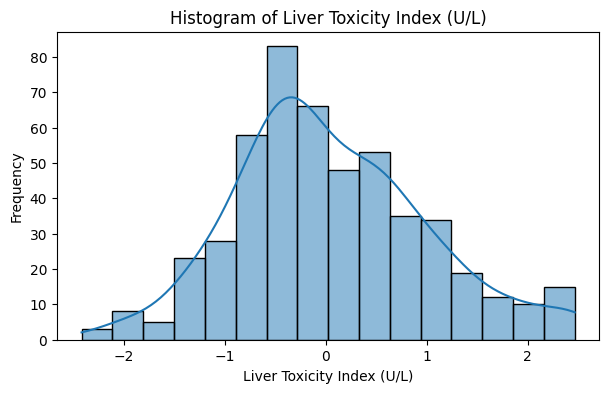

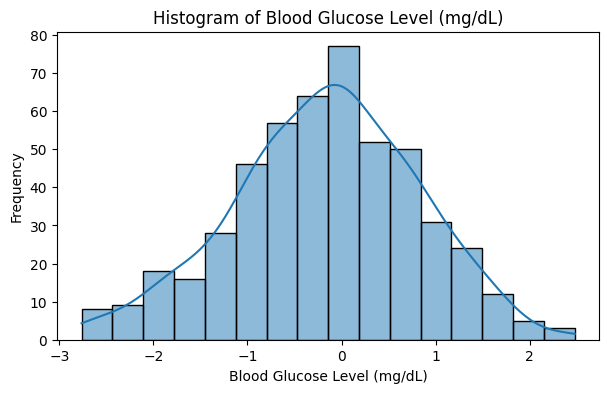

In [13]:
numerical_cols = features.select_dtypes(include=['float64','int']).columns
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

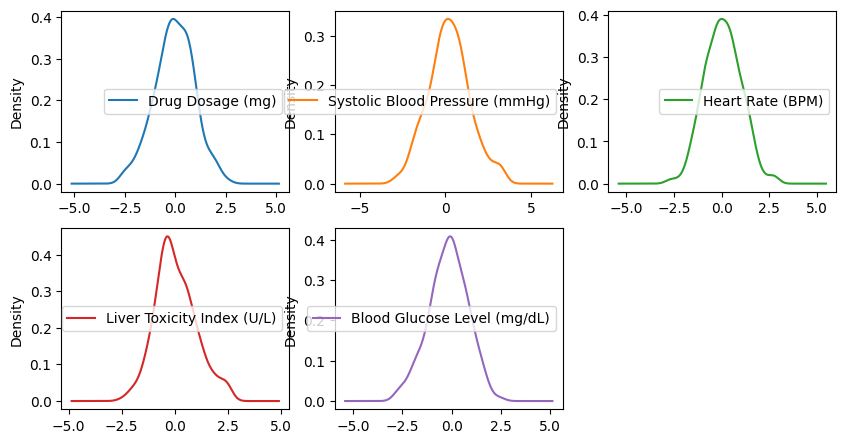

In [14]:
features.plot(kind='density', subplots=True, layout=(3,3), figsize=(10,8), sharex=False)
plt.show()

In [15]:
corr_matrix=features.corr()

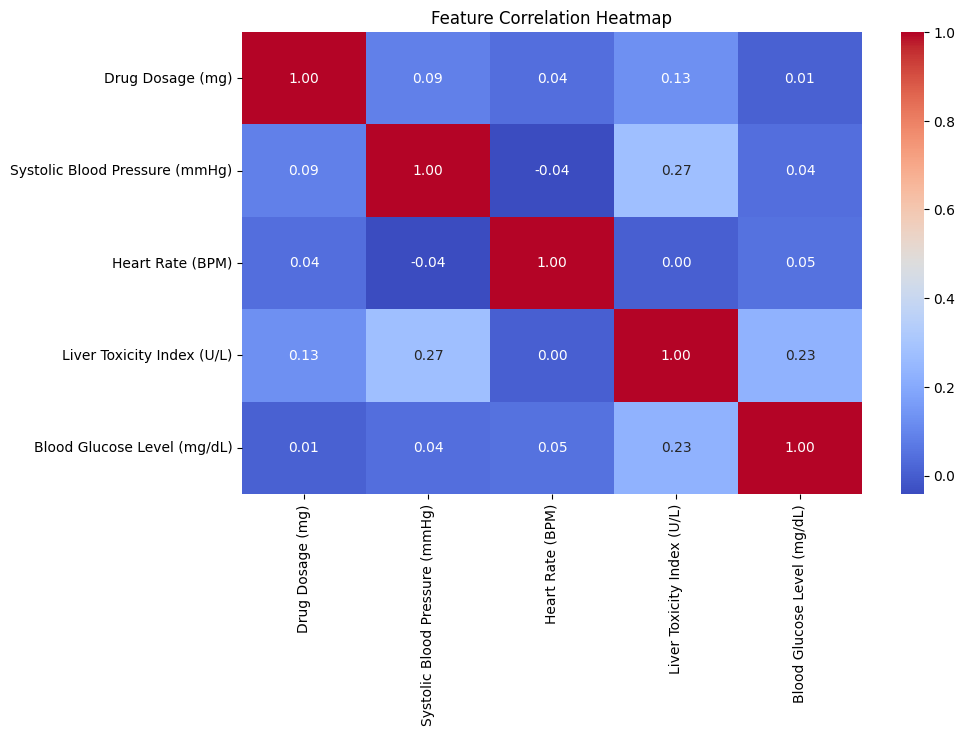

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [17]:
features.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355
4,0.377100,0.538410,-0.029263,1.896015,-0.960130


### Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [19]:
features= df.drop(columns=['Drug Response'])
target=df[['Drug Response']]

In [23]:
#### train_test_split
x_train,x_test,y_train,y_test= train_test_split(features,target,train_size=0.8,random_state=100,stratify=df['Drug Response'])
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400, 1)
(100, 1)


In [24]:
### linear Kernel
svc=SVC(C=1,kernel='linear')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_train)
train_acc=accuracy_score(y_train,y_pred)
y_pred1=svc.predict(x_test)
test_acc=accuracy_score(y_test,y_pred1)
print('Train_Accuracy:',train_acc,',','Test_accuracy:',test_acc)

Train_Accuracy: 0.725 , Test_accuracy: 0.74


In [25]:
x_test.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL)
295,-0.646227,-0.084383,1.775311,0.202843,-2.542089
69,0.548884,1.151605,-0.254956,0.796077,0.607005
263,-0.483061,-0.416244,0.146793,2.142717,-0.850920
104,0.000207,-1.601083,-0.009300,-0.413624,0.631401
190,1.211944,1.996296,0.261251,-0.777713,1.178022


In [26]:
y_pred1

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [27]:
#### Meshgrid
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.463913,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


### Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.


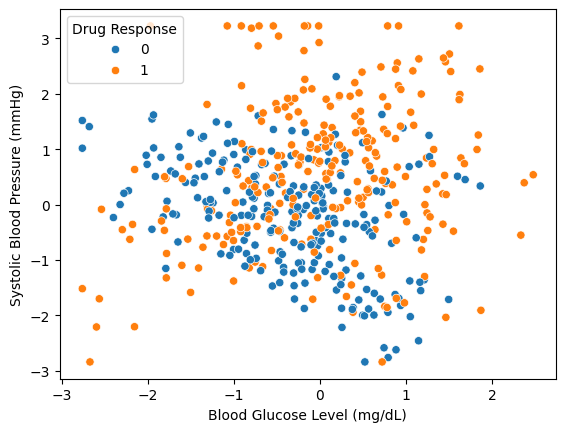

In [31]:
## Scatter plot
sns.scatterplot(data=df,x='Blood Glucose Level (mg/dL)',y='Systolic Blood Pressure (mmHg)',hue='Drug Response')
plt.show()

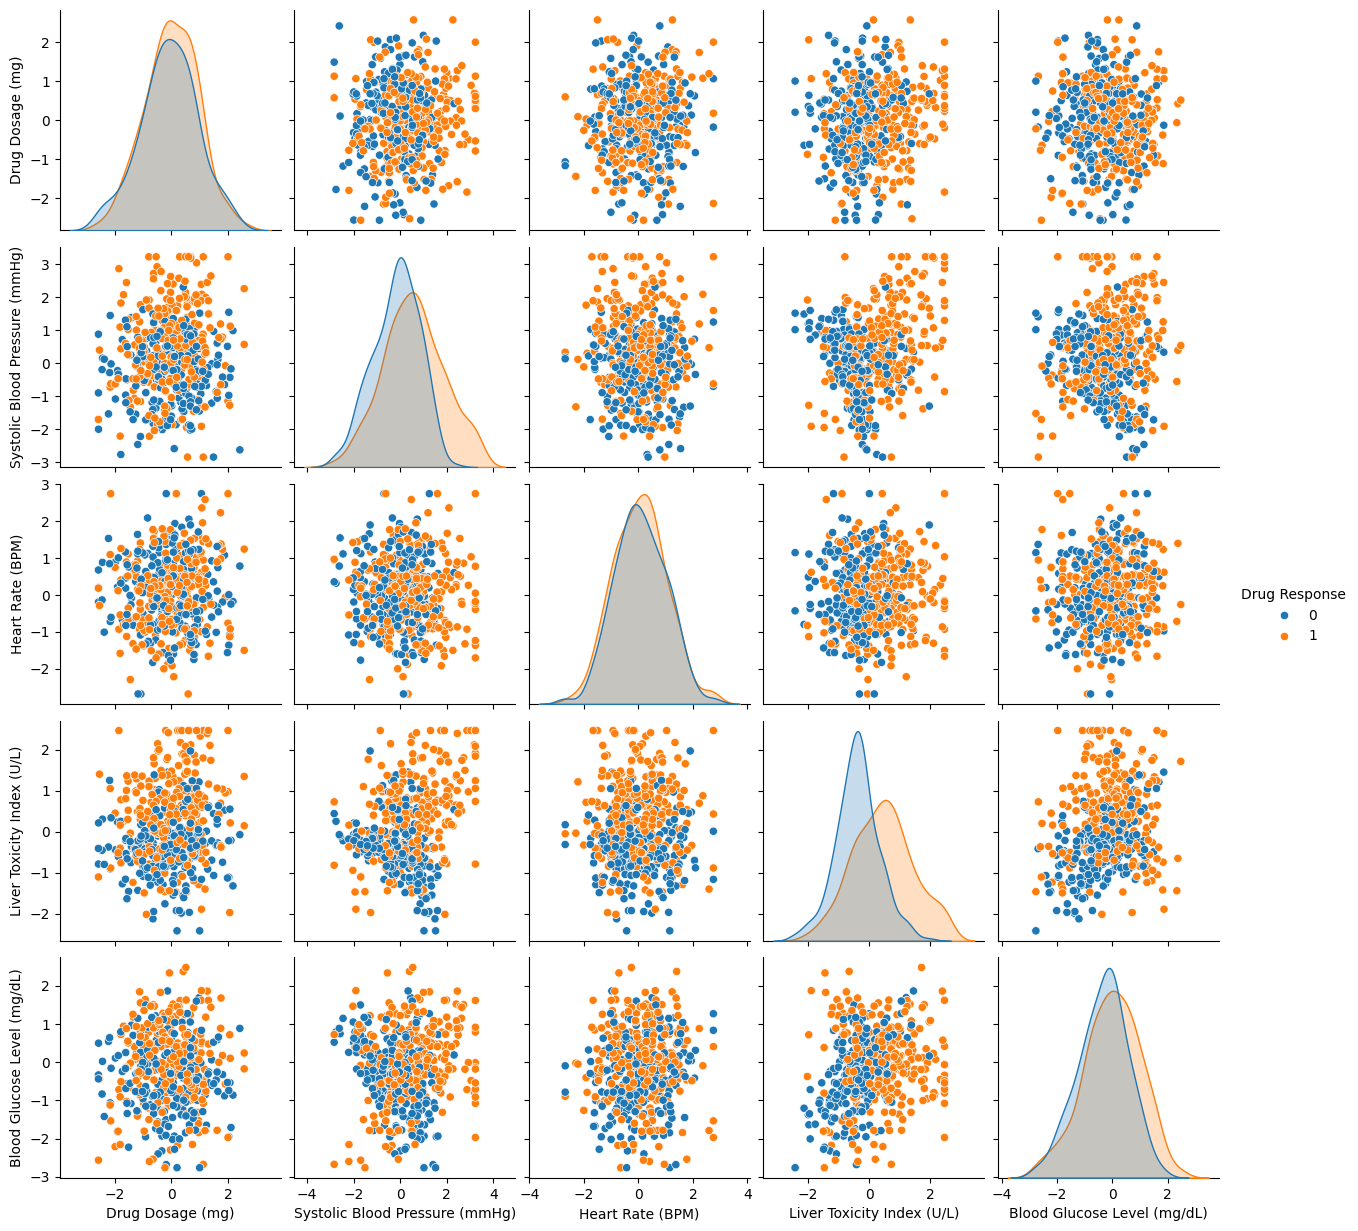

In [32]:
sns.pairplot(df, hue='Drug Response', diag_kind='kde')
plt.show()

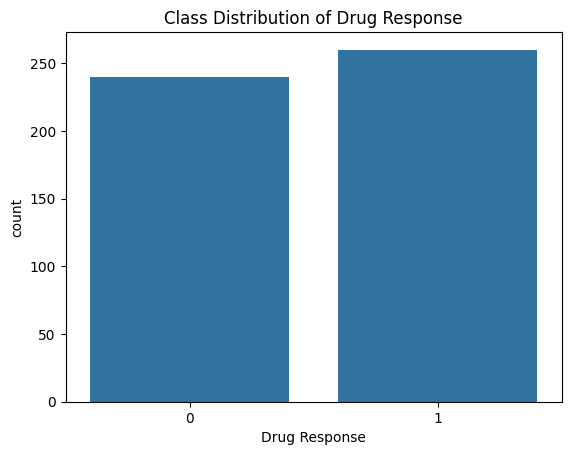

In [33]:
sns.countplot(x='Drug Response', data=df)
plt.title("Class Distribution of Drug Response")
plt.show()

In [34]:
df['Drug Response'].value_counts()

Drug Response
1    260
0    240
Name: count, dtype: int64

### Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).


In [45]:
columns = ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 
           'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 
           'Blood Glucose Level (mg/dL)']

min_max_dict = {col: (df[col].min() - 1, df[col].max() + 1) for col in columns}

print(min_max_dict)

{'Drug Dosage (mg)': (np.float64(-3.5667328734783985), np.float64(3.5658810828304035)), 'Systolic Blood Pressure (mmHg)': (np.float64(-3.839982200906558), np.float64(4.226188669099171)), 'Heart Rate (BPM)': (np.float64(-3.6865539738222575), np.float64(3.749171291217805)), 'Liver Toxicity Index (U/L)': (np.float64(-3.4160827211088276), np.float64(3.463912530291167)), 'Blood Glucose Level (mg/dL)': (np.float64(-3.7646201812348314), np.float64(3.480459563128914))}


In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [72]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [75]:
#### rbf kernel
svc= SVC(C=1,kernel='sigmoid',gamma=0.2)
svc.fit(x_train,y_train)
y_pred= svc.predict(x_train)
train_acc=accuracy_score(y_train,y_pred)
y_pred1= svc.predict(x_test)
test_acc=accuracy_score(y_test,y_pred1)

In [78]:

# Precision, Recall, F1 (on test set)
precision = precision_score(y_test,y_pred1)
recall = recall_score(y_test, y_pred1)
f1 = f1_score(y_test, y_pred1)
print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

Train Accuracy: 0.6150, Test Accuracy: 0.6200
Precision: 0.6207, Recall: 0.6923, F1-score: 0.6545


In [59]:
#### Sigmoid kernel
svc= SVC(C=1,kernel='sigmoid',gamma=0.2)
svc.fit(x_train,y_train)
y_pred= svc.predict(x_train)
train_acc=accuracy_score(y_train,y_pred)
y_pred1= svc.predict(x_test)
test_acc=accuracy_score(y_test,y_pred1)
print('Train_Accuracy:',train_acc,',','Test_accuracy:',test_acc)

Train_Accuracy: 0.615 , Test_accuracy: 0.62


### Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.


In [91]:
# Select 2 features for visualization
features = ['Systolic Blood Pressure (mmHg)', 'Blood Glucose Level (mg/dL)']
x = df[features]
y = df['Drug Response']

# Train/test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)


In [92]:

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Train SVM with RBF kernel
svc = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svc.fit(x_train_scaled, y_train)



SVC(random_state=42)

In [93]:
# Create meshgrid for decision boundary
h = 0.02
x_min, x_max = x_train_scaled[:, 0].min() - 1, x_train_scaled[:, 0].max() + 1
y_min, y_max = x_train_scaled[:, 1].min() - 1, x_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

In [94]:
# Predict on meshgrid
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

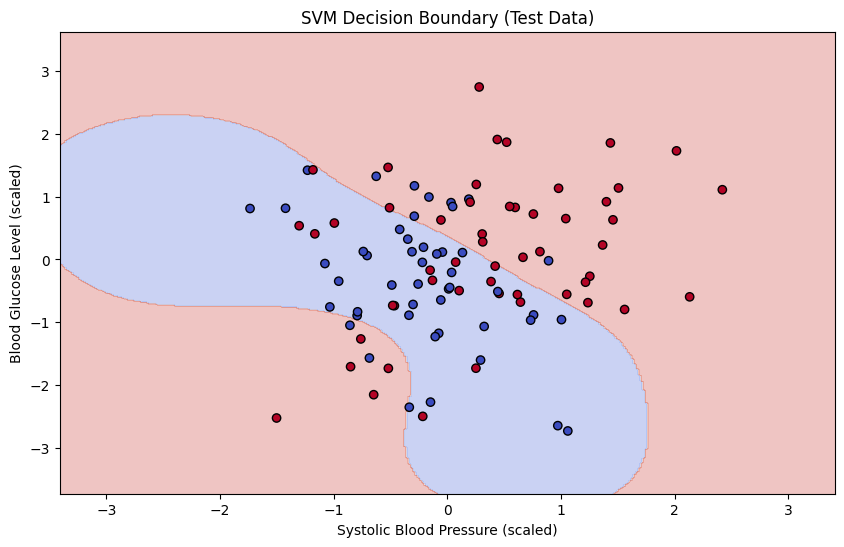

In [95]:
# Plot decision boundary
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x_test_scaled[:, 0], x_test_scaled[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('Systolic Blood Pressure (scaled)')
plt.ylabel('Blood Glucose Level (scaled)')
plt.title('SVM Decision Boundary (Test Data)')
plt.show()

### Task 6: Parameter Tuning and Optimization
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.


In [80]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Grid search with 5-fold CV
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

# Train SVM with best parameters
best_svc = grid.best_estimator_
y_test_pred = best_svc.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy with best parameters:", test_acc)

Best parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.73
Test Accuracy with best parameters: 0.73


### Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).


In [81]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for k in kernels:
    svc = SVC(kernel=k, C=1.0, gamma='scale', random_state=42)
    svc.fit(X_train_scaled, y_train)
    y_pred = svc.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[k] = acc

print("SVM Accuracy by Kernel:")
for k, acc in results.items():
    print(f"{k:7s} : {acc:.4f}")

SVM Accuracy by Kernel:
linear  : 0.7000
poly    : 0.6200
rbf     : 0.7300
sigmoid : 0.6400
